<a href="https://colab.research.google.com/github/Hafsahshaikh/AIML_Projects_and_Labs-IHub-Data-IIITH/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [7]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # TODO: Calculate the linear output (w * x + b)
                prediction = np.dot(X[i], self.w) + self.b

                # TODO: If prediction is a mistake (y * prediction <= 0):
                # Update weights: w = w + lr * y * x
                # Update bias: b = b + lr * y
                if y[i]*prediction <= 0:
                  self.w = self.w + self.lr * y[i] * X[i]
                  self.b = self.b + self.lr * y[i]
                  count += 1

            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_p = WaterPerceptron()
model_p.fit(X_train, y_train)

accuracy = np.mean(model_p.predict(X_test) == y_test)
print(f"Perceptron Accuracy: {accuracy * 100:.2f}%")

Perceptron Accuracy: 50.15%


# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [8]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # TODO: 1. Compute linear output: z = Xw + b
            # TODO: 2. Calculate gradients:
            # dw = (1/n) * X.T.dot(z - y)
            # db = (1/n) * sum(z - y)

            z = np.dot(X, self.w) + self.b
            dw = (1/n) * np.dot(X.T, z - y)
            db = (1/n) * np.sum(z - y)

            # TODO: 3. Update w and b: w = w - lr * dw

            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

            cost = (1/(2 * n)) * np.sum((z - y)**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# Train model
model_gd = GDWaterClassifier()
model_gd.fit(X_train, y_train)

# Prediction
pred_gd = model_gd.predict(X_test)

# Accuracy
accuracy = np.mean(pred_gd == y_test)
print("Gradient Descent Accuracy:", accuracy)

Gradient Descent Accuracy: 0.6280487804878049


# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [9]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # TODO: Implement the Margin Condition check: y_i * (w * x_i + b) >= 1

                condition = y[i] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])


    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# Train model
model_margin = MarginWaterClassifier()
model_margin.fit(X_train, y_train)

# Prediction
pred_margin = model_margin.predict(X_test)

# Accuracy
accuracy = np.mean(pred_margin == y_test)
print("Margin Classifier Accuracy:", accuracy)


Margin Classifier Accuracy: 0.6280487804878049


# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

**1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.**

**A.**
*   **Perceptron**: The graph shows the number of misclassified samples in each epoch. Since the Perceptron updates its weights only when it makes a mistake, the number of mistakes can increase or decrease abruptly, making the graph irregular.
*   **Gradient Descent:** The graph of the cost function decreases smoothly because Gradient Descent minimizes the error over the entire dataset at every iteration. The updates are based on the average gradient rather than individual mistakes, resulting in stable convergence.

The Gradient Descent plot smoother because Gradient Descent computes the average error across all training samples before updating the weights. This produces small and consistent updates that gradually reduce the loss. In contrast, the Perceptron updates its weights immediately after each misclassified sample, causing sudden changes and a less smooth learning curve.



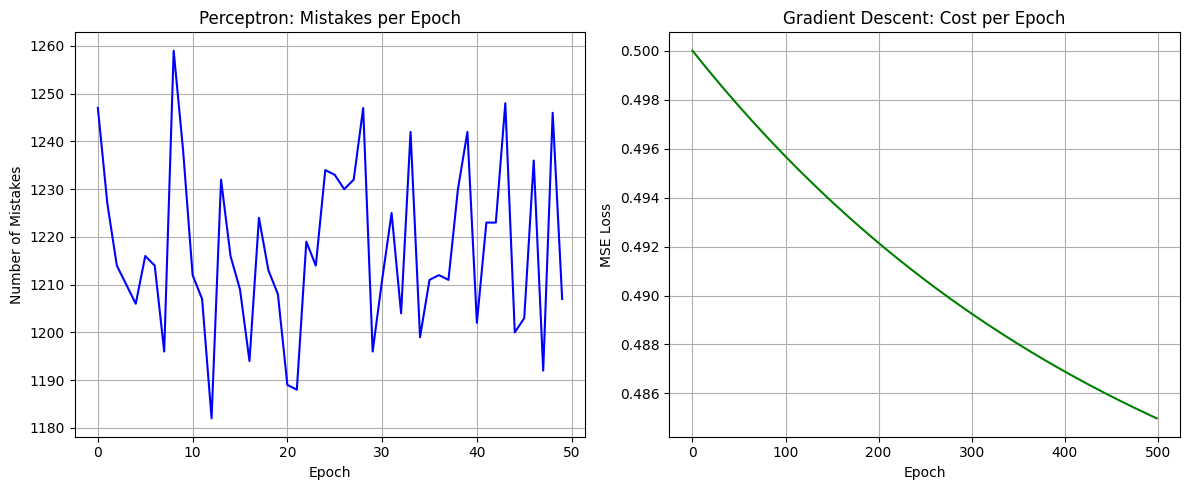

In [10]:
plt.figure(figsize=(12,5))

# Perceptron Mistakes
plt.subplot(1,2,1)
plt.plot(model_p.mistakes, color="blue")
plt.title("Perceptron: Mistakes per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Mistakes")
plt.grid(True)

# Gradient Descent Cost
plt.subplot(1,2,2)
plt.plot(model_gd.cost_history, color="green")
plt.title("Gradient Descent: Cost per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

**2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.**

In [11]:
# Predictions
pred_p = model_p.predict(X_test)
pred_gd = model_gd.predict(X_test)
pred_margin = model_margin.predict(X_test)

# Accuracy
acc_p = np.mean(pred_p == y_test)
acc_gd = np.mean(pred_gd == y_test)
acc_margin = np.mean(pred_margin == y_test)

print("Test Accuracy")
print("--------------------------")
print(f"Perceptron          : {acc_p:.4f}")
print(f"Gradient Descent    : {acc_gd:.4f}")
print(f"Margin Classifier   : {acc_margin:.4f}")

Test Accuracy
--------------------------
Perceptron          : 0.5015
Gradient Descent    : 0.6280
Margin Classifier   : 0.6280


**3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?**

**A.** The Margin Classifier is the preferred model because it not only classifies samples correctly but also maintains a safety margin around the decision boundary. This makes it more dependable for classifying water samples that are close to the boundary, reducing the risk of incorrect predictions on unseen data.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

**A.** If the learning rate is set too high (e.g., 1.0), the Gradient Descent model may fail to converge.
*   The weight updates become very large.
*   Instead of moving gradually toward the minimum loss, the algorithm overshoots the optimal solution.
*   The loss may increase instead of decrease.
*   In extreme cases, the model may diverge, causing the loss to fluctuate or become very large.

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

**A.** We converted the labels from {0, 1} to {-1, 1} because many linear classifiers, such as the Perceptron and Margin (Hinge Loss) Classifier, are mathematically designed to work with labels of -1 and 1.

Using {-1, 1}:
*   Makes the update rules simpler.
*   Allows the margin condition y × (w·x + b) to work correctly.
*   Provides a symmetric representation of the two classes around zero.
*   If labels remained {0, 1}, the hinge loss and margin calculations would not work correctly without modifying the equations.

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*

**A**. Among the three algorithms, the Margin Water Classifier (Hinge Loss + L2 Regularization) is the best choice for handling noisy data.

Reason:



*   The Perceptron attempts to classify every training sample correctly, making it sensitive to noisy or incorrectly labeled data.
*   Gradient Descent with MSE is more stable than the Perceptron but can still be affected by outliers because large errors contribute heavily to the squared loss.
*   The Margin Classifier uses Hinge Loss to maximize the separation (margin) between classes and L2 Regularization to prevent overly large weights, making it more robust to noise and improving generalization.